In [ ]:
# Load libraries and data
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Set style for better-looking plots
plt.rcParams['figure.figsize'] = (12, 8)

# Load the merged data
# data = pd.read_csv('../data/raw/item_level_data.csv')
data = pd.read_csv('../data/processed/processed_item_level_data.csv')
data.head(3)

                participant_id          condition  week  imageid time_point  \
0     560379c9e372c00011bd4a90         Persuasive     0        0     before   
1     560379c9e372c00011bd4a90         Persuasive     0        0       with   
2     560379c9e372c00011bd4a90         Persuasive     0      100      after   
3     560379c9e372c00011bd4a90         Persuasive     0        1     before   
4     560379c9e372c00011bd4a90         Persuasive     0        1       with   
...                        ...                ...   ...      ...        ...   
4531  6832419ec81a26698b331047  Critical Thinking     4       87       with   
4532  6832419ec81a26698b331047  Critical Thinking     4      187      after   
4533  6832419ec81a26698b331047  Critical Thinking     4       83     before   
4534  6832419ec81a26698b331047  Critical Thinking     4       83       with   
4535  6832419ec81a26698b331047  Critical Thinking     4      183      after   

      accuracy  belief  confidence ground_truth   s

In [8]:
data["week"].value_counts()

week
0    1512
2    1512
4    1512
Name: count, dtype: int64

In [17]:
# # Process data for plotting

# # Calculate accuracy for before, with, after AI
# data['before_accuracy'] = (data['before_AI_Real_Fake'].str.lower() == data['ground_truth_with_AI'].str.lower()).astype(int) #* data['confidence_rating_before_AI'] / 100
# data['with_accuracy'] = (data['with_AI_Real_Fake'].str.lower() == data['ground_truth_with_AI'].str.lower()).astype(int) #* data['confidence_rating_with_AI'] / 100
# data['after_accuracy'] = (data['after_AI_Real_Fake'].str.lower() == data['after_AI_ground_truth'].str.lower()).astype(int) #* data['confidence_rating_after_AI'] / 100

# # Numeric belief for before, with, after AI (Fake 0, Real 1)
# data['before_belief'] = (data['before_AI_Real_Fake'].str.lower() == 'real').astype(int)
# data['with_belief'] = (data['with_AI_Real_Fake'].str.lower() == 'real').astype(int)
# data['after_belief'] = (data['after_AI_Real_Fake'].str.lower() == 'real').astype(int)

# # Reshape data for plotting
# processed_df = []
# for idx, row in data.iterrows():
#     for time_point, acc_col, belief_col, conf_col, gt_col, seen_col in [('before', 'before_accuracy', 'before_belief', 'confidence_rating_before_AI', 'ground_truth_with_AI', 'with_AI_seen_before'), ('with', 'with_accuracy', 'with_belief', 'confidence_rating_with_AI', 'ground_truth_with_AI', 'with_AI_seen_before'), ('after', 'after_accuracy', 'after_belief', 'confidence_rating_after_AI', 'after_AI_ground_truth', 'after_AI_seen_before')]:
#         processed_df.append({
#             # for week just the int e.g. week 0 becomes 0
#             'participant_id': row['participant_id'], 'condition': row['condition'], 'week': int(row['week'].split(' ')[1]), 'imageid': row['imageid'],
#             'time_point': time_point, 'accuracy': row[acc_col], 'belief': row[belief_col], 'confidence': row[conf_col], 'ground_truth': row[gt_col].lower(), 'seen': row[seen_col]=='Yes'
#         })
# processed_df = pd.DataFrame(processed_df)

# # Create new imageids to ensure uniqueness across weeks and time points
# processed_df['imageid'] = processed_df.groupby(['week', 'time_point'])['imageid'].transform(lambda x: pd.factorize(x)[0]) + processed_df['week'] * 20 + (processed_df['time_point'] == 'after') * 100

# # Remove people who are not in week 4
# ids_w4 = set(processed_df[processed_df['week'] == 4]['participant_id'].unique())
# plot_df = processed_df[processed_df['participant_id'].isin(ids_w4)]

# # Save processed data
# plot_df.head(3)

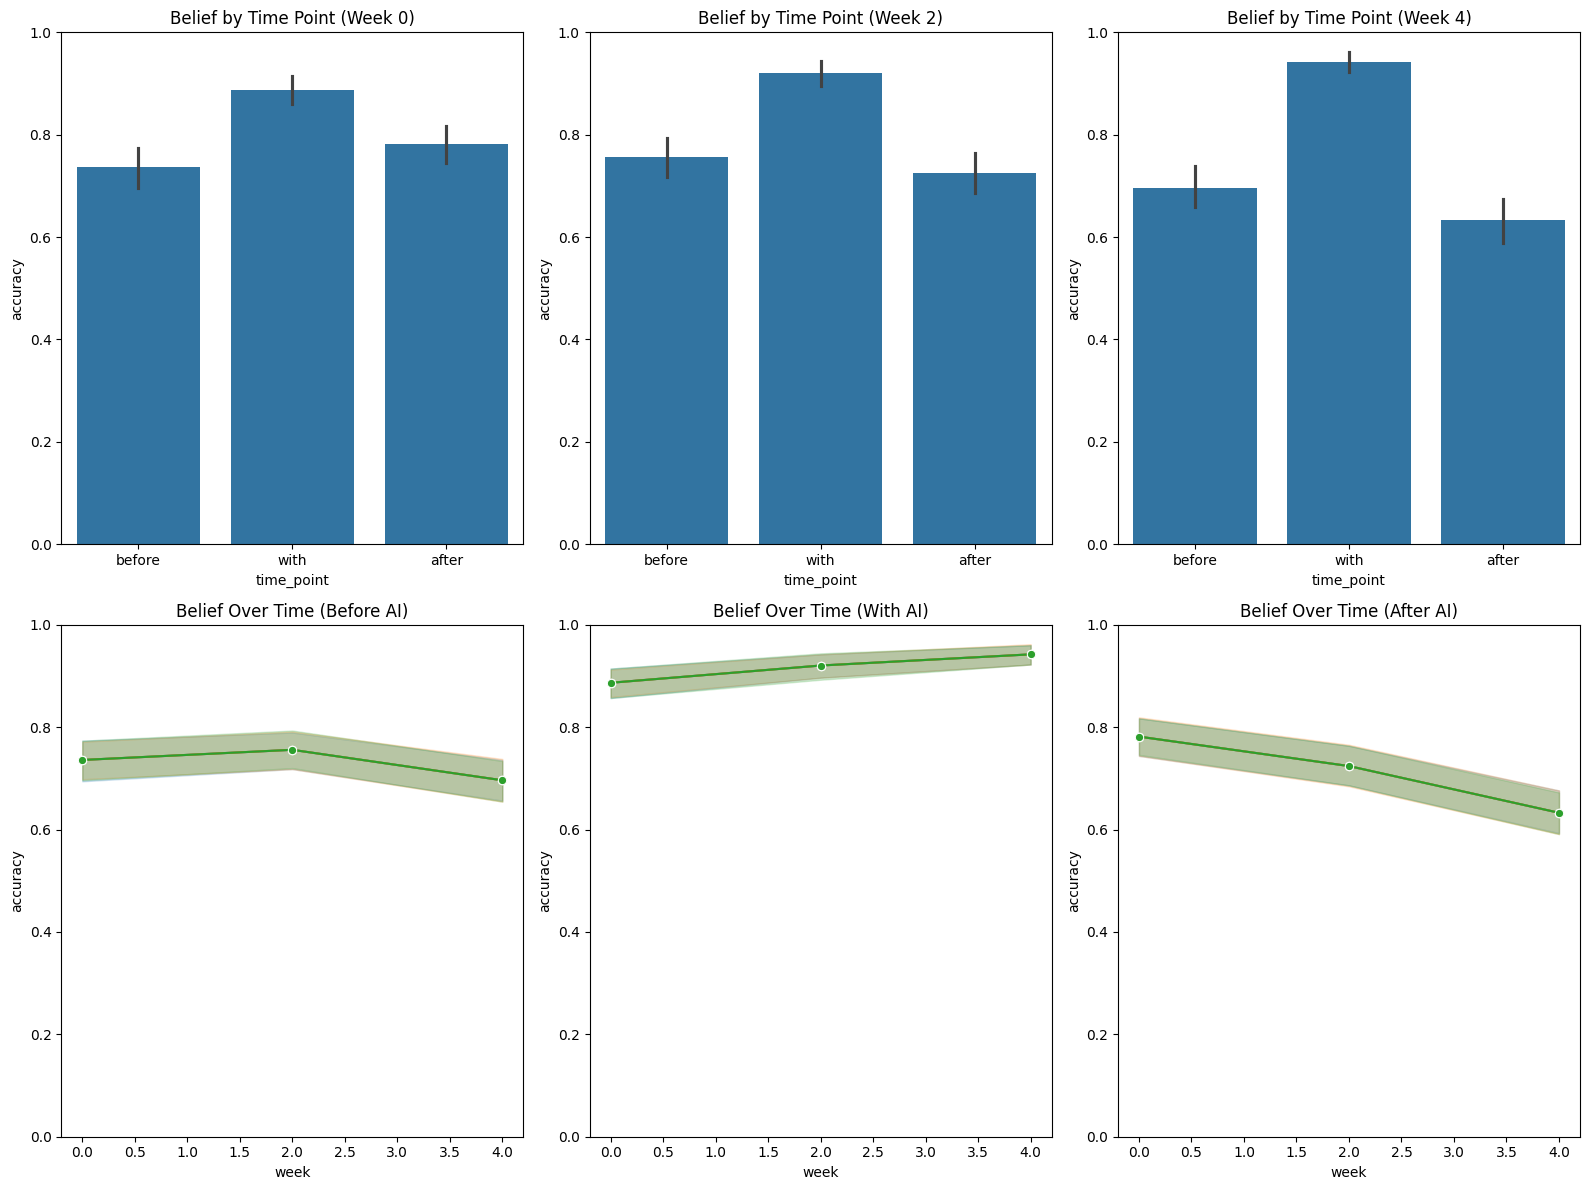

Plotting for ground truth: fake with 2266 entries


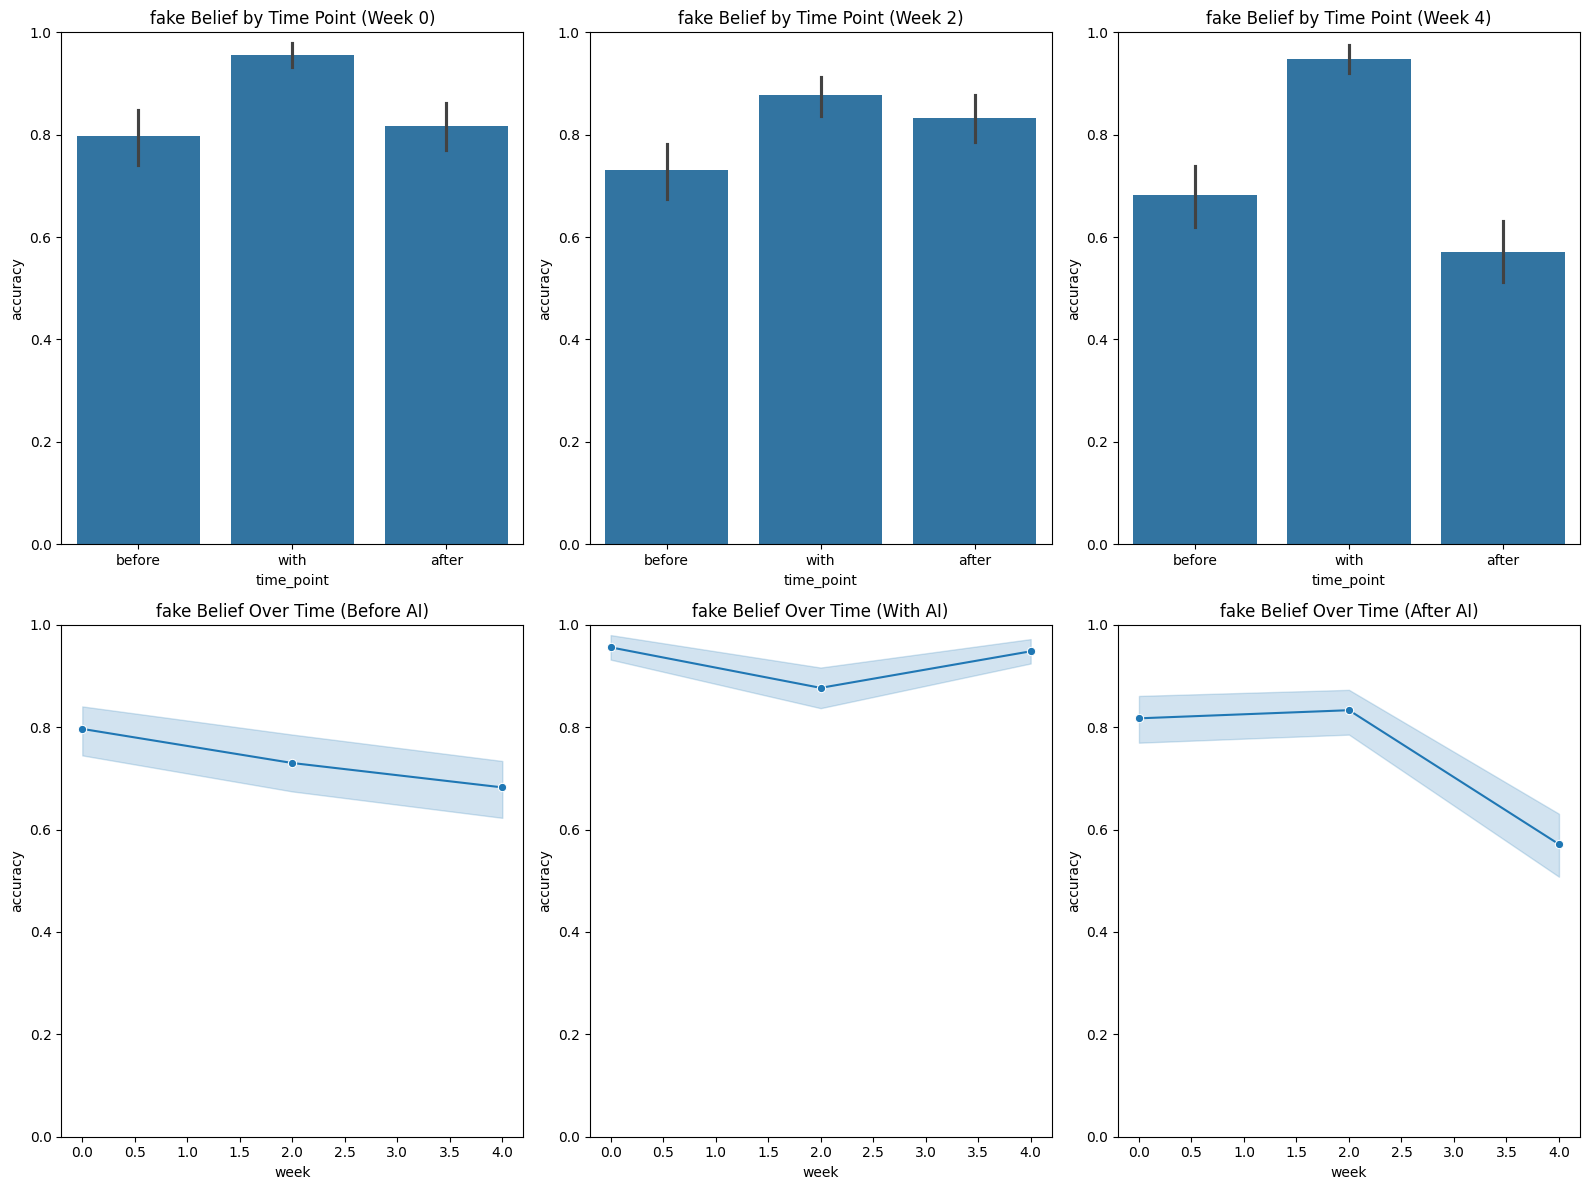

Plotting for ground truth: real with 2270 entries


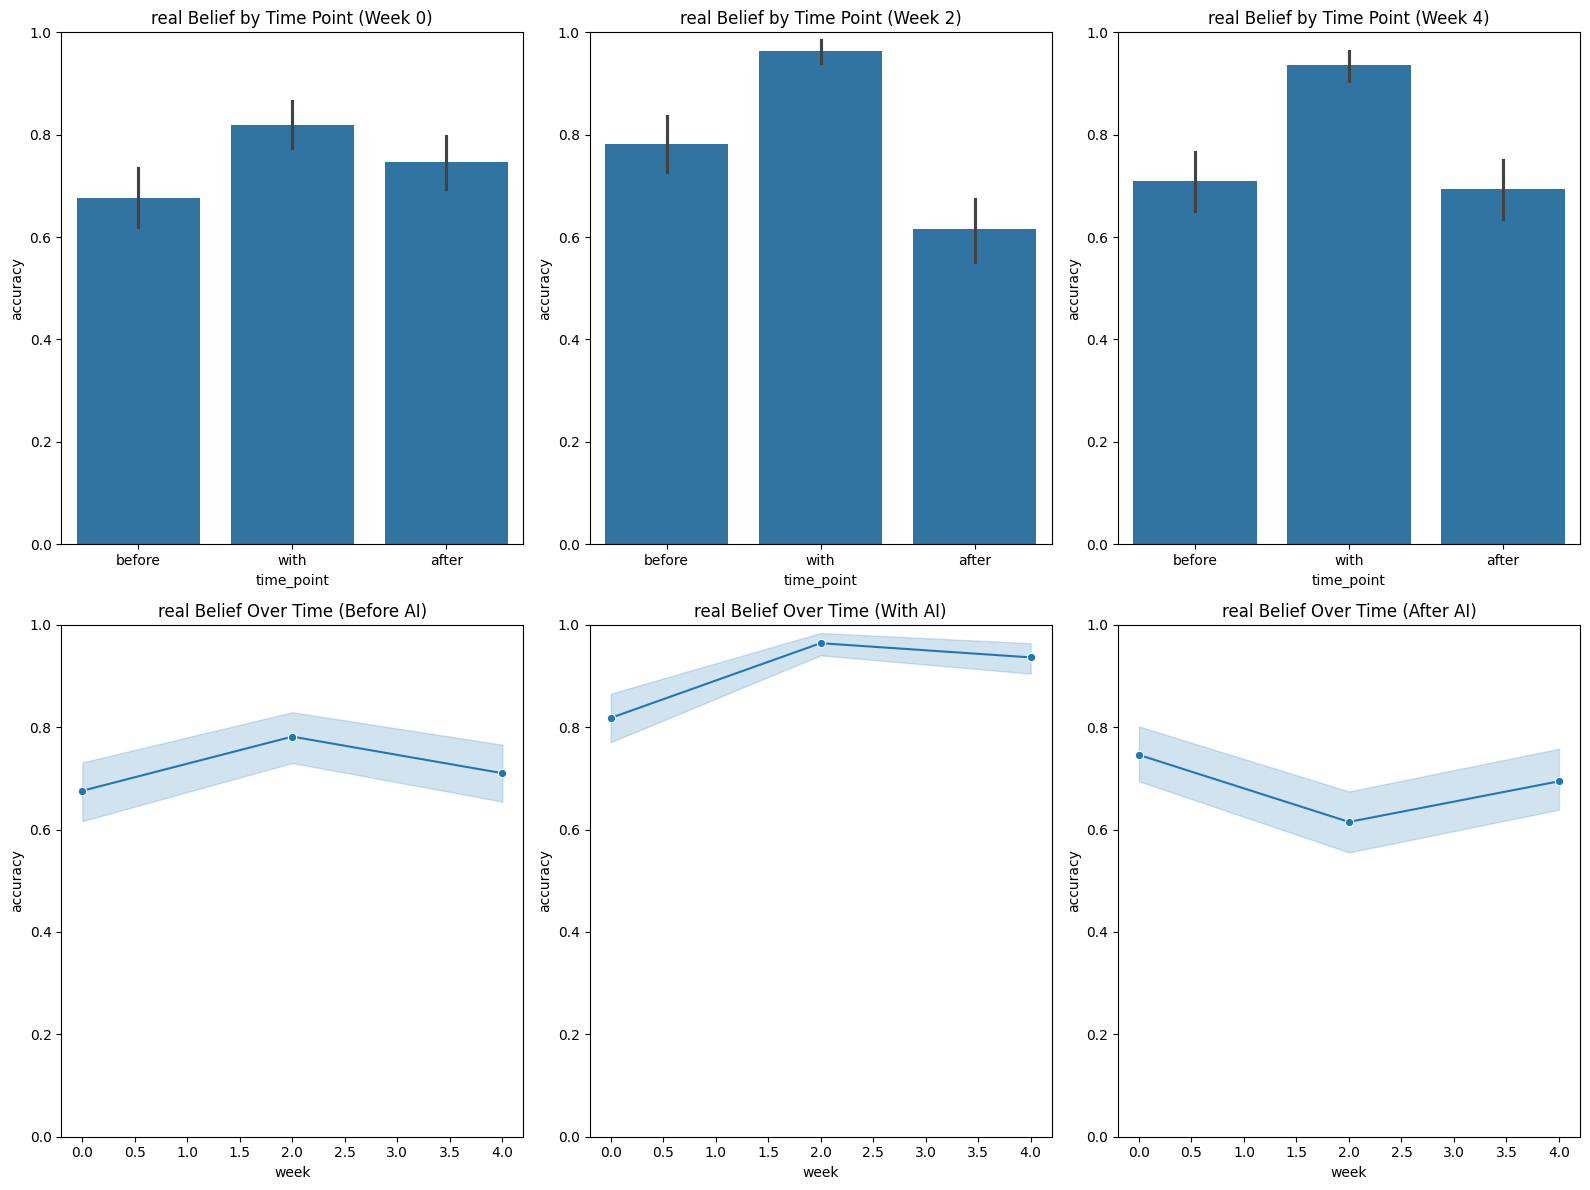

In [42]:
# Create plots
fig, axes = plt.subplots(2, 3, figsize=(16, 12))

# set ylimits for all plots
for ax in axes.flatten(): ax.set_ylim(0, 1)

# 1. Line plot: no AI conditions (prior, Week 0&2&4 no AI)
for i, week in enumerate(data['week'].unique()):
    sns.barplot(data=data[data['week'] == week], x='time_point', y='accuracy', ax=axes[0,i])
    axes[0,i].set_title(f'Belief by Time Point (Week {week})')


# 4. Line plot: with AI conditions (prior, Week 0&2&4 with AI)
    for i, time in enumerate(['before', 'with', 'after']):
        sns.lineplot(data=data[data.time_point == time], x='week', y='accuracy', marker='o', ax=axes[1,i])
        axes[1,i].set_title(f'Belief Over Time ({time.capitalize()} AI)')
        axes[1,i].set_ylim(0, 1)
        
    plt.tight_layout()
plt.show()

# 5. For fake and real separately
for truth in data.ground_truth.unique():

    print(f"Plotting for ground truth: {truth} with {len(data[data.ground_truth == truth])} entries")
    data_subset = data[data.ground_truth == truth].copy()
    fig, axes = plt.subplots(2, 3, figsize=(16, 12))

    for i, week in enumerate(data_subset['week'].unique()):
        sns.barplot(data=data_subset[data_subset['week'] == week], x='time_point', y='accuracy', ax=axes[0,i])
        axes[0,i].set_title(f'{truth} Belief by Time Point (Week {week})')
        axes[0,i].set_ylim(0, 1)
        #axes[0,i].set_xticks([0, 2, 4])
        #axes[0,i].set_xticklabels(['Week 0', 'Week 2', 'Week 4'])


    # 4. Line plot: with AI conditions (prior, Week 0&2&4 with AI)
    for i, time in enumerate(['before', 'with', 'after']):
        sns.lineplot(data=data_subset[data_subset.time_point == time], x='week', y='accuracy', marker='o', ax=axes[1,i])
        axes[1,i].set_title(f'{truth} Belief Over Time ({time.capitalize()} AI)')
        axes[1,i].set_ylim(0, 1)
        #axes[1,i].set_xticks([0, 2, 4])
        #axes[1,i].set_xticklabels(['Week 0', 'Week 2', 'Week 4'])
    
    plt.tight_layout()
    plt.show()



AI Literacy vs Accuracy plots:
AI Usage vs Accuracy plots:
AI Image Usage vs Accuracy plots:


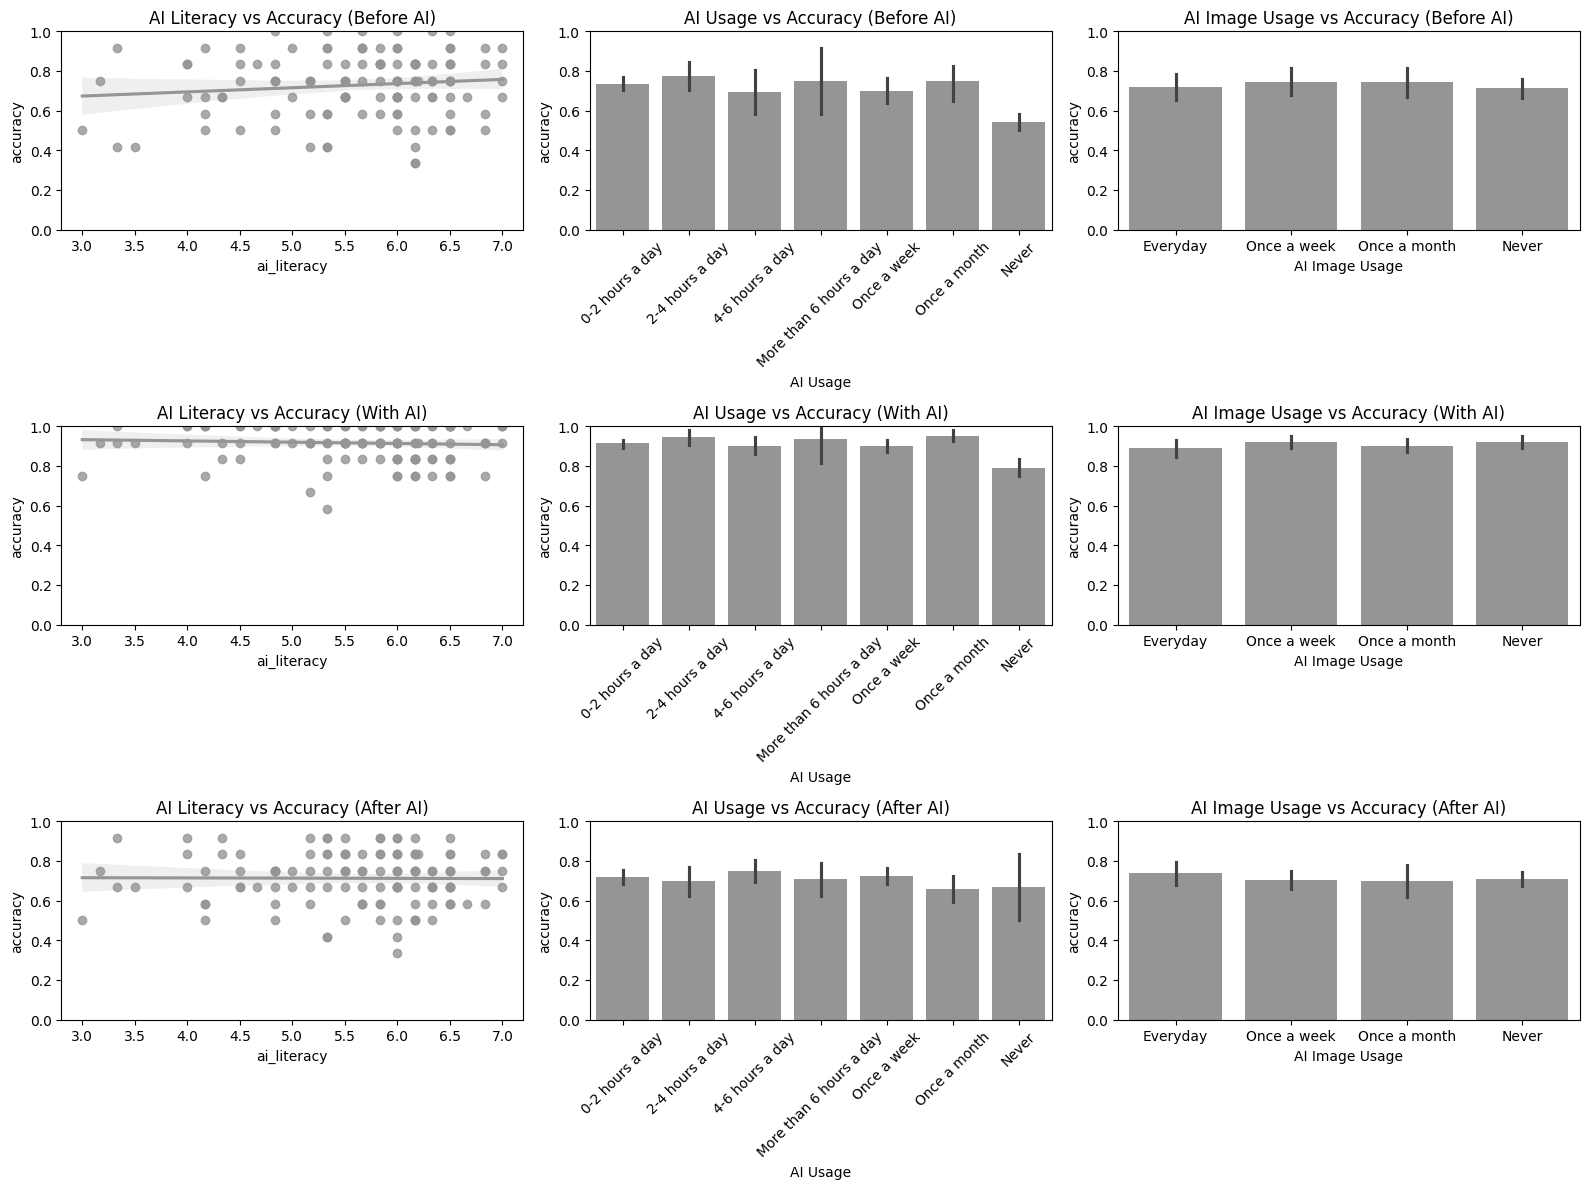

Column unique values:
AI Usage: ['2-4 hours a day' 'Once a week' '0-2 hours a day' '4-6 hours a day'
 'Once a month' 'More than 6 hours a day' 'Never']
AI Image Usage: ['Once a week' 'Rarely' 'Once a month' 'Never' 'Everyday']


In [13]:
# all figures should be grey
# custom palette with light greys
sns.set_palette(sns.color_palette("Greys", n_colors=1))

fig, axes = plt.subplots(3, 3, figsize=(16, 12))

# Plot ai literacy over accuracy
print("AI Literacy vs Accuracy plots:")
for i, time in enumerate(['before', 'with', 'after']):
    # on participant level and include ai_literacy and average accuracy cols
    df_participant = data[data.time_point == time].groupby('participant_id')[["ai_literacy", "accuracy"]].mean().reset_index()
    sns.regplot(data=df_participant, x='ai_literacy', y='accuracy',ax=axes[i, 0])
    axes[i, 0].set_title(f'AI Literacy vs Accuracy ({time.capitalize()} AI)')
    axes[i, 0].set_ylim(0, 1)

# Plot ai_usage over accuracy
print("AI Usage vs Accuracy plots:")
for i, time in enumerate(['before', 'with', 'after']):
    # on participant level and include ai_usage and average accuracy cols
    df_participant = data[data.time_point == time].groupby(['participant_id', 'ai_usage'])["accuracy"].mean().reset_index()
    sns.barplot(data=df_participant, x='ai_usage', y='accuracy', ax=axes[i, 1],
                order=['0-2 hours a day', '2-4 hours a day', '4-6 hours a day', 'More than 6 hours a day', 
                       'Once a week', 'Once a month', 'Never']
                )
    axes[i, 1].set_title(f'AI Usage vs Accuracy ({time.capitalize()} AI)')
    axes[i, 1].set_ylim(0, 1)
    axes[i, 1].set_xlabel('AI Usage')
    # rotate x labels
    for tick in axes[i, 1].get_xticklabels():
        tick.set_rotation(45)

# Plot ai_image_usage over accuracy
print("AI Image Usage vs Accuracy plots:")
for i, time in enumerate(['before', 'with', 'after']):
    # on participant level and include ai_image_usage and average accuracy cols
    df_participant = data[data.time_point == time].groupby(['participant_id', 'ai_image_usage'])["accuracy"].mean().reset_index()
    sns.barplot(data=df_participant, x='ai_image_usage', y='accuracy',ax=axes[i, 2],
                order=['Everyday', 'Once a week', 'Once a month', 'Never']
                )
    axes[i, 2].set_title(f'AI Image Usage vs Accuracy ({time.capitalize()} AI)')
    axes[i, 2].set_ylim(0, 1)
    axes[i, 2].set_xlabel('AI Image Usage')

plt.tight_layout()
plt.show()

# print column unique values for usage
print("Column unique values:")
print("AI Usage:", data['ai_usage'].unique())
print("AI Image Usage:", data['ai_image_usage'].unique())

AI Literacy vs Accuracy plots:
AI Usage vs Accuracy plots:
AI Image Usage vs Accuracy plots:


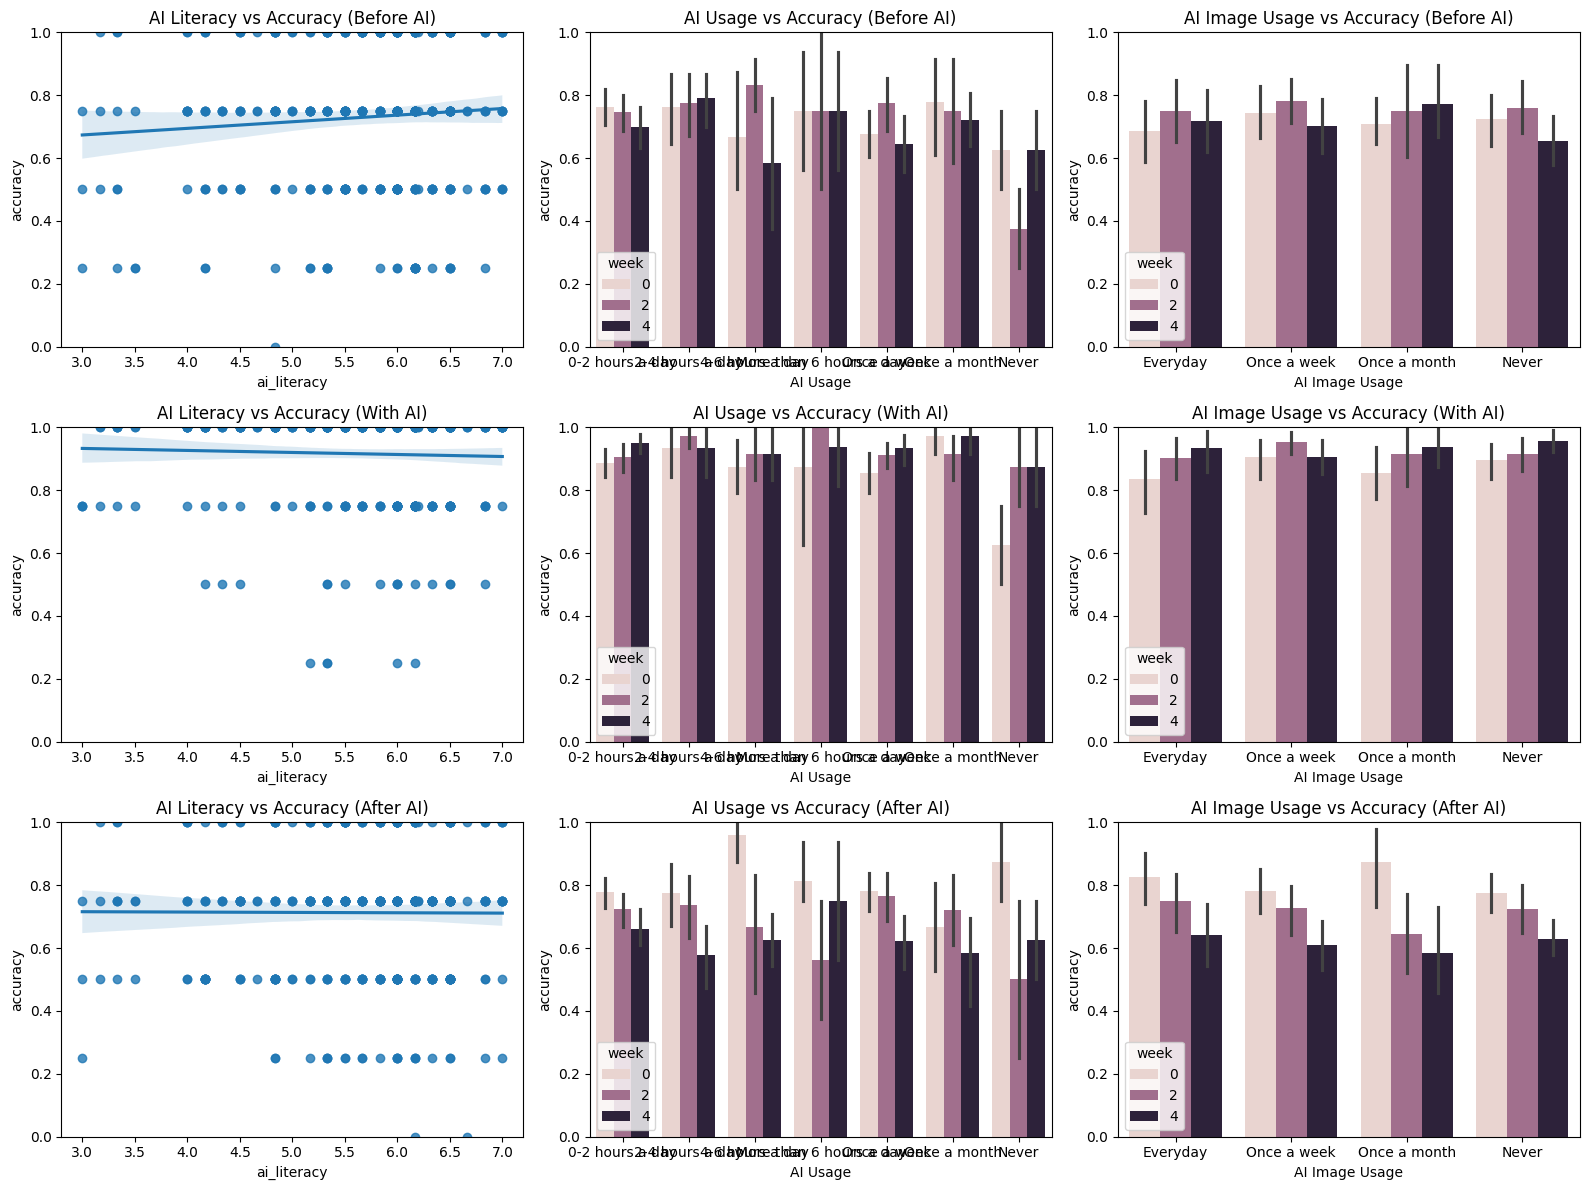

Column unique values:
AI Usage: ['2-4 hours a day' 'Once a week' '0-2 hours a day' '4-6 hours a day'
 'Once a month' 'More than 6 hours a day' 'Never']
AI Image Usage: ['Once a week' 'Rarely' 'Once a month' 'Never' 'Everyday']


In [62]:
# For each week
fig, axes = plt.subplots(3, 3, figsize=(16, 12))

# Plot ai literacy over accuracy
print("AI Literacy vs Accuracy plots:")
for i, time in enumerate(['before', 'with', 'after']):
    # on participant level and include ai_literacy and average accuracy cols
    df_participant = data[data.time_point == time].groupby(['participant_id', 'week'])[["ai_literacy", "accuracy"]].mean().reset_index()
    sns.regplot(data=df_participant, x='ai_literacy', y='accuracy',ax=axes[i, 0])
    axes[i, 0].set_title(f'AI Literacy vs Accuracy ({time.capitalize()} AI)')
    axes[i, 0].set_ylim(0, 1)

# Plot ai_usage over accuracy
print("AI Usage vs Accuracy plots:")
for i, time in enumerate(['before', 'with', 'after']):
    # on participant level and include ai_usage and average accuracy cols
    df_participant = data[data.time_point == time].groupby(['participant_id', 'ai_usage', "week"])["accuracy"].mean().reset_index()
    sns.barplot(data=df_participant, x='ai_usage', y='accuracy', ax=axes[i, 1],
                order=['0-2 hours a day', '2-4 hours a day', '4-6 hours a day', 'More than 6 hours a day', 
                       'Once a week', 'Once a month', 'Never'],
                hue='week'
                )
    axes[i, 1].set_title(f'AI Usage vs Accuracy ({time.capitalize()} AI)')
    axes[i, 1].set_ylim(0, 1)
    axes[i, 1].set_xlabel('AI Usage')

# Plot ai_image_usage over accuracy
print("AI Image Usage vs Accuracy plots:")
for i, time in enumerate(['before', 'with', 'after']):
    # on participant level and include ai_image_usage and average accuracy cols
    df_participant = data[data.time_point == time].groupby(['participant_id', 'ai_image_usage', 'week'])["accuracy"].mean().reset_index()
    sns.barplot(data=df_participant, x='ai_image_usage', y='accuracy',ax=axes[i, 2],
                order=['Everyday', 'Once a week', 'Once a month', 'Never'],
                hue='week'
                )
    axes[i, 2].set_title(f'AI Image Usage vs Accuracy ({time.capitalize()} AI)')
    axes[i, 2].set_ylim(0, 1)
    axes[i, 2].set_xlabel('AI Image Usage')

plt.tight_layout()
plt.show()

# print column unique values for usage
print("Column unique values:")
print("AI Usage:", data['ai_usage'].unique())
print("AI Image Usage:", data['ai_image_usage'].unique())